# S6E4 — Predicting Irrigation Need
**Task**: Multiclass classification → `Irrigation_Need` (Low / Medium / High)  
**Metric**: Balanced Accuracy Score  
**Deadline**: April 30, 2026

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import mutual_info_classif
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## Load Data

In [2]:
# Environment-aware path switching
is_kaggle = os.path.exists("/kaggle/input")
input_dir = "/kaggle/input/competitions/playground-series-s6e4" if is_kaggle else "./data"
output_dir = "/kaggle/working" if is_kaggle else "./submissions"

print(f"Environment: {'Kaggle' if is_kaggle else 'Local'}")
print(f"Input dir : {input_dir}")
print(f"Output dir: {output_dir}")

train_df = pd.read_csv(f"{input_dir}/train.csv")
test_df  = pd.read_csv(f"{input_dir}/test.csv")

print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
train_df.head(3)

Environment: Kaggle
Input dir : /kaggle/input/competitions/playground-series-s6e4
Output dir: /kaggle/working

Train shape: (630000, 21)
Test shape : (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low


## Exploratory Data Analysis

In [3]:
TARGET = "Irrigation_Need"

# Target distribution
print("=== Target distribution ===")
vc = train_df[TARGET].value_counts()
print(vc)
print(f"\nClass balance (%):\n{(vc / len(train_df) * 100).round(2)}")

# Missing values
print("\n=== Missing values (train) ===")
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

# Dtypes summary
print("\n=== Column dtypes ===")
print(train_df.dtypes.value_counts())

# Feature types
def is_categorical(series):
    return series.dtype == "object" or hasattr(series.dtype, "name") and series.dtype.name in ("string", "str")

cat_features = [c for c in train_df.columns if c not in [TARGET, "id"] and is_categorical(train_df[c])]
num_features = [c for c in train_df.columns if c not in [TARGET, "id"] and not is_categorical(train_df[c])]
print(f"\nCategorical features ({len(cat_features)}): {cat_features}")
print(f"Numeric features   ({len(num_features)}): {num_features}")

=== Target distribution ===
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Class balance (%):
Irrigation_Need
Low       58.72
Medium    37.95
High       3.33
Name: count, dtype: float64

=== Missing values (train) ===
None

=== Column dtypes ===
float64    11
object      9
int64       1
Name: count, dtype: int64

Categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numeric features   (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


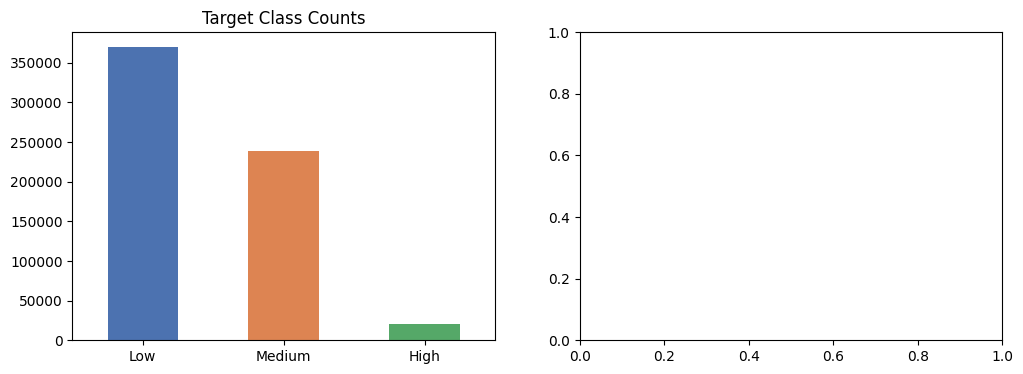

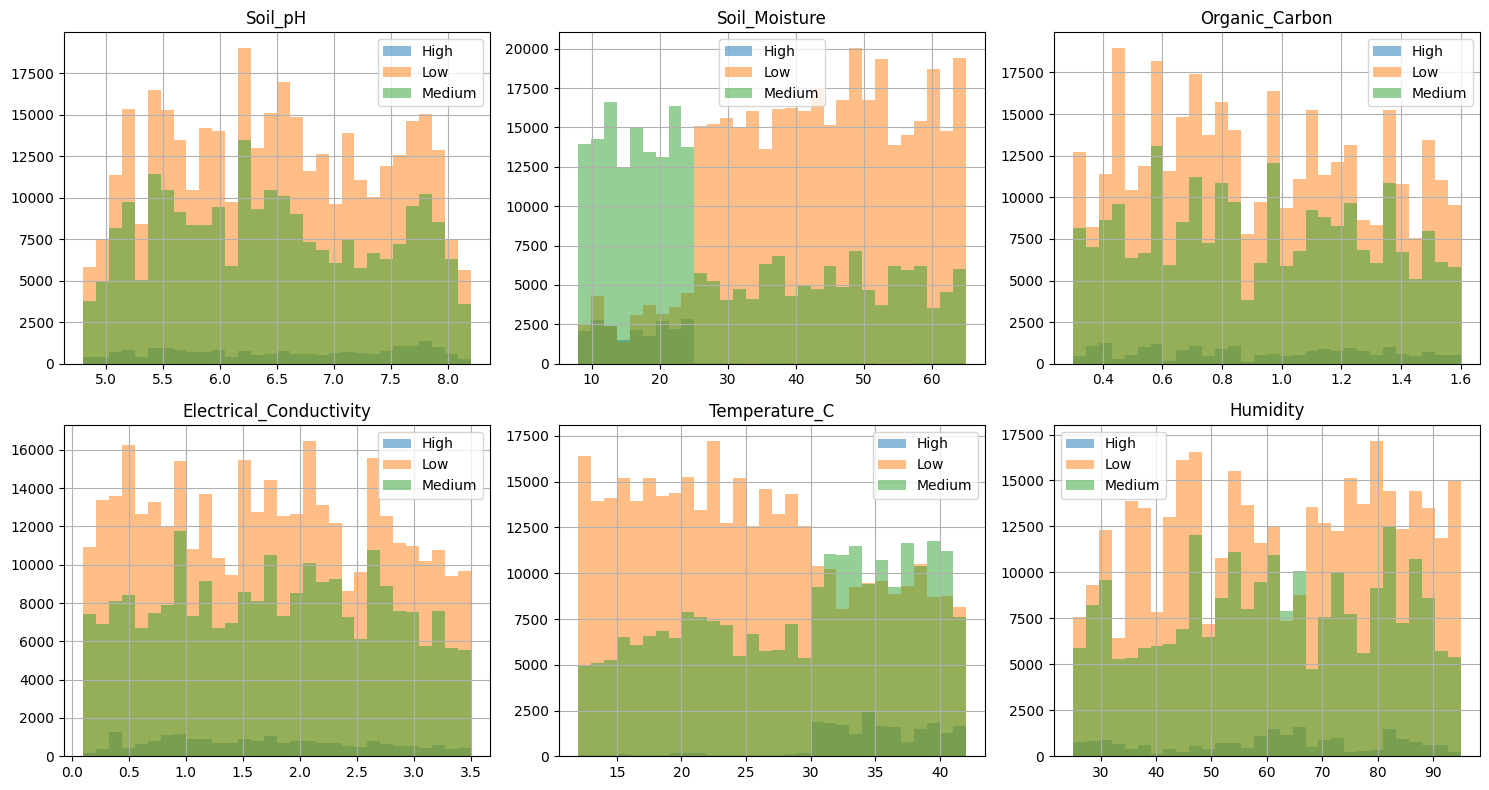

<Figure size 640x480 with 0 Axes>

In [4]:
# Target distribution bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Target Class Counts")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Numeric feature distributions (first 6)
if num_features:
    cols_to_plot = num_features[:6]
    fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
    for i, col in enumerate(cols_to_plot):
        ax = axes2[i // 3][i % 3]
        for label, grp in train_df.groupby(TARGET):
            grp[col].hist(ax=ax, alpha=0.5, bins=30, label=label)
        ax.set_title(col)
        ax.legend()
    plt.tight_layout()
    plt.show()

plt.tight_layout()
plt.show()

## In-Depth EDA For Impact Discovery
Focused checks for `Rainfall_mm`, `Soil_Moisture`, `Water_Source`, and `Irrigation_Type`, plus feature-signal ranking to verify which variables are most informative.

=== Focus numeric stats by class ===
                Rainfall_mm                   Soil_Moisture                 \
                       mean   median      std          mean median     std   
Irrigation_Need                                                              
High                989.157   764.95  800.312        17.670  17.09   7.480   
Low                1500.534  1498.88  584.805        43.306  44.01  13.421   
Medium             1444.475  1463.59  618.450        29.744  23.89  16.625   

                Previous_Irrigation_mm                 
                                  mean median     std  
Irrigation_Need                                        
High                            63.053  66.65  32.197  
Low                             61.718  59.38  35.548  
Medium                          63.182  62.20  32.295  

=== Target mix inside Water_Source ===
Irrigation_Need  High    Low  Medium
Water_Source                        
Groundwater      2.35  60.10   37.55
Rainwat

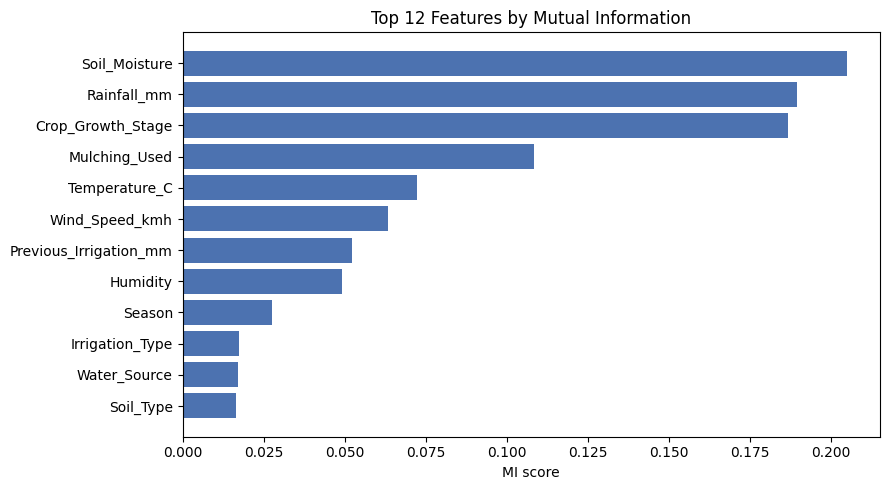

In [5]:
focus_num = ["Rainfall_mm", "Soil_Moisture", "Previous_Irrigation_mm"]
focus_cat = ["Water_Source", "Irrigation_Type"]

# 1) Numeric profile by class
print("=== Focus numeric stats by class ===")
print(train_df.groupby(TARGET)[focus_num].agg(["mean", "median", "std"]).round(3))

# 2) Focus categorical vs target distribution
for col in focus_cat:
    print(f"\n=== Target mix inside {col} ===")
    mix = pd.crosstab(train_df[col], train_df[TARGET], normalize="index")
    print((mix * 100).round(2))

# 3) Interaction view: Water source x Irrigation type
pair_mix = pd.crosstab(
    [train_df["Water_Source"], train_df["Irrigation_Type"]],
    train_df[TARGET],
    normalize="index"
)
print("\n=== Water_Source x Irrigation_Type target mix (top 12 rows) ===")
print((pair_mix * 100).round(2).head(12))

# 4) Quantile bucket analysis for rainfall and soil moisture
eda_tmp = train_df[["Rainfall_mm", "Soil_Moisture", TARGET]].copy()
eda_tmp["rain_bin"] = pd.qcut(eda_tmp["Rainfall_mm"], q=10, labels=False, duplicates="drop")
eda_tmp["moist_bin"] = pd.qcut(eda_tmp["Soil_Moisture"], q=10, labels=False, duplicates="drop")

rain_high_rate = (
    eda_tmp.groupby("rain_bin")[TARGET]
    .apply(lambda s: (s == "High").mean())
    .rename("High_rate")
)
moist_high_rate = (
    eda_tmp.groupby("moist_bin")[TARGET]
    .apply(lambda s: (s == "High").mean())
    .rename("High_rate")
)

print("\n=== High-class rate by Rainfall decile ===")
print((rain_high_rate * 100).round(2))
print("\n=== High-class rate by Soil Moisture decile ===")
print((moist_high_rate * 100).round(2))

# 5) Fast signal ranking with mutual information
probe = train_df.drop(columns=[TARGET, "id"]).copy()
for c in probe.columns:
    if pd.api.types.is_string_dtype(probe[c]) or probe[c].dtype == "object":
        probe[c] = probe[c].astype("category").cat.codes

y_probe = train_df[TARGET].map({"Low": 0, "Medium": 1, "High": 2}).astype(int)
mi = mutual_info_classif(probe, y_probe, discrete_features="auto", random_state=42)
mi_df = pd.DataFrame({"feature": probe.columns, "mi": mi}).sort_values("mi", ascending=False)

print("\n=== Top 15 features by mutual information ===")
print(mi_df.head(15).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(mi_df.head(12)["feature"][::-1], mi_df.head(12)["mi"][::-1], color="#4C72B0")
plt.title("Top 12 Features by Mutual Information")
plt.xlabel("MI score")
plt.tight_layout()
plt.show()

## Preprocessing & Feature Engineering

In [6]:
# ---- Target encoding ----
CLASS_ORDER = ["Low", "Medium", "High"]
label_map = {c: i for i, c in enumerate(CLASS_ORDER)}
inv_label_map = {i: c for c, i in label_map.items()}
y = train_df[TARGET].map(label_map).astype(int)

print("Target encoded:", label_map)
print(y.value_counts().sort_index())

# ---- Feature engineering (interactions only) ----
train_fe = train_df.drop(columns=[TARGET]).copy()
test_fe = test_df.copy()

for df in [train_fe, test_fe]:
    df["rainfall_x_moisture"] = df["Rainfall_mm"] * df["Soil_Moisture"]
    df["rainfall_per_prev_irrig"] = df["Rainfall_mm"] / (df["Previous_Irrigation_mm"] + 1.0)
    df["moisture_minus_prev_irrig"] = df["Soil_Moisture"] - df["Previous_Irrigation_mm"]

    df["water_source__irrigation_type"] = (
        df["Water_Source"].astype(str) + "__" + df["Irrigation_Type"].astype(str)
    )
    df["crop__season"] = df["Crop_Type"].astype(str) + "__" + df["Season"].astype(str)

    # Bucket moisture for source-moisture interaction
    df["moisture_bucket"] = pd.qcut(df["Soil_Moisture"], q=8, duplicates="drop").astype(str)
    df["water_source__moisture_bucket"] = (
        df["Water_Source"].astype(str) + "__" + df["moisture_bucket"].astype(str)
    )

# ---- Build base matrices ----
all_features = [c for c in train_fe.columns if c != "id"]
X_train_base = train_fe[all_features].copy()
X_test_base = test_fe[all_features].copy()

cat_features = [c for c in all_features if is_categorical(X_train_base[c])]
num_features = [c for c in all_features if c not in cat_features]

print(f"\nCategorical features ({len(cat_features)}):")
print(cat_features)
print(f"\nNumeric features ({len(num_features)}):")
print(num_features)

# ---- Label encode categoricals for tree models ----
for col in cat_features:
    le = LabelEncoder()
    combo = pd.concat([X_train_base[col], X_test_base[col]], axis=0).astype(str)
    le.fit(combo)
    X_train_base[col] = le.transform(X_train_base[col].astype(str))
    X_test_base[col] = le.transform(X_test_base[col].astype(str))

# ---- Scale numerics ----
scaler = StandardScaler()
X_train_base[num_features] = scaler.fit_transform(X_train_base[num_features])
X_test_base[num_features] = scaler.transform(X_test_base[num_features])

# ---- Final training matrix: interaction-only (no pairwise TE) ----
X_train_df = X_train_base.copy()
X_test_df = X_test_base.copy()

X_train = X_train_df.values.astype(np.float32)
X_test = X_test_df.values.astype(np.float32)
feature_names = X_train_df.columns.tolist()
n_classes = len(CLASS_ORDER)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Classes: {n_classes}")

Target encoded: {'Low': 0, 'Medium': 1, 'High': 2}
Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64

Categorical features (12):
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'water_source__irrigation_type', 'crop__season', 'moisture_bucket', 'water_source__moisture_bucket']

Numeric features (14):
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'rainfall_x_moisture', 'rainfall_per_prev_irrig', 'moisture_minus_prev_irrig']

X_train: (630000, 26), X_test: (270000, 26)
Classes: 3


## Model Training
5-fold StratifiedKFold CV with LightGBM, XGBoost, and CatBoost. OOF predictions stored for leakage-safe ensemble.

In [ ]:
def build_lgb(n_classes):
    return lgb.LGBMClassifier(
        n_estimators=1200,
        learning_rate=0.04,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        objective="multiclass",
        num_class=n_classes,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

def build_xgb(n_classes):
    return xgb.XGBClassifier(
        n_estimators=450,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

def build_cat(n_classes):
    # Params from Optuna search (60 trials, 2026-04-29); best 3-fold = 0.969922
    return CatBoostClassifier(
        iterations=1388,
        learning_rate=0.035922606902684895,
        depth=4,
        l2_leaf_reg=11.312251057160324,
        bagging_temperature=0.7607850486168974,
        random_strength=5.612771975694963,
        border_count=204,
        grow_policy="Lossguide",
        loss_function="MultiClass",
        eval_metric="Accuracy",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=0,
    )

print("Model builders defined.")

Model builders defined.


In [8]:
def run_cv(model_fn, X, y, X_test, n_classes, n_folds=5, name="model"):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof_proba = np.zeros((len(X), n_classes))
    test_proba = np.zeros((len(X_test), n_classes))
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y.values[tr_idx], y.values[val_idx]

        model = model_fn()

        # Use validation-aware fitting where supported for faster/safer training.
        try:
            if name == "LGB":
                model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="multi_logloss", callbacks=[lgb.early_stopping(100, verbose=False)])
            elif name == "XGB":
                model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            elif name == "CAT":
                model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
            else:
                model.fit(X_tr, y_tr)
        except TypeError:
            model.fit(X_tr, y_tr)

        val_pred = model.predict_proba(X_val)
        oof_proba[val_idx] = val_pred
        test_proba += model.predict_proba(X_test) / n_folds

        fold_pred_labels = np.argmax(val_pred, axis=1)
        score = balanced_accuracy_score(y_val, fold_pred_labels)
        scores.append(score)
        print(f"  Fold {fold + 1}: {score:.5f}")

    oof_labels = np.argmax(oof_proba, axis=1)
    overall = balanced_accuracy_score(y.values, oof_labels)
    print(f"  [{name}] OOF Balanced Accuracy: {overall:.5f}  (mean folds: {np.mean(scores):.5f})")
    return oof_proba, test_proba, overall

print("CV helper defined.")

CV helper defined.


In [9]:
print("=== LightGBM ===")
lgb_oof, lgb_test, lgb_score = run_cv(
    lambda: build_lgb(n_classes), X_train, y, X_test, n_classes, n_folds=5, name="LGB"
)


=== LightGBM ===
  Fold 1: 0.96542
  Fold 2: 0.96610
  Fold 3: 0.96673
  Fold 4: 0.96603
  Fold 5: 0.96631
  [LGB] OOF Balanced Accuracy: 0.96612  (mean folds: 0.96612)


In [10]:
print("\n=== XGBoost ===")
xgb_oof, xgb_test, xgb_score = run_cv(
    lambda: build_xgb(n_classes), X_train, y, X_test, n_classes, n_folds=5, name="XGB"
)



=== XGBoost ===
  Fold 1: 0.96066
  Fold 2: 0.96264
  Fold 3: 0.96174
  Fold 4: 0.96238
  Fold 5: 0.96182
  [XGB] OOF Balanced Accuracy: 0.96185  (mean folds: 0.96185)


In [11]:
print("\n=== CatBoost ===")
cat_oof, cat_test, cat_score = run_cv(
    lambda: build_cat(n_classes), X_train, y, X_test, n_classes, n_folds=5, name="CAT"
)



=== CatBoost ===
  Fold 1: 0.96724
  Fold 2: 0.96890
  Fold 3: 0.96984
  Fold 4: 0.96792
  Fold 5: 0.96822
  [CAT] OOF Balanced Accuracy: 0.96842  (mean folds: 0.96842)


In [12]:
print(f"\nSummary: LGB={lgb_score:.5f}, XGB={xgb_score:.5f}, CAT={cat_score:.5f}")



Summary: LGB=0.96612, XGB=0.96185, CAT=0.96842


## Model Evaluation

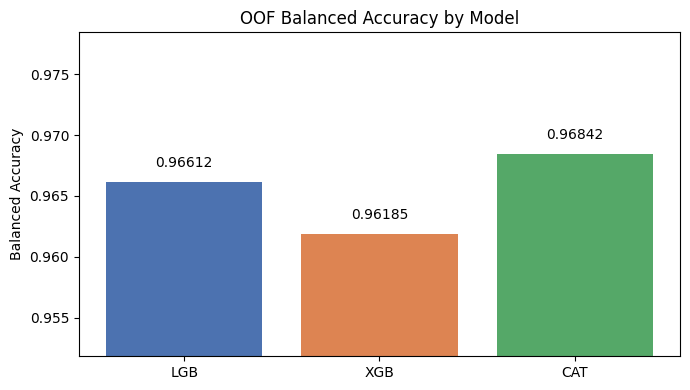

In [13]:
# CV score bar chart
model_names  = ["LGB", "XGB", "CAT"]
model_scores = [lgb_score, xgb_score, cat_score]

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, model_scores, color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylim(min(model_scores) - 0.01, max(model_scores) + 0.01)
for bar, sc in zip(bars, model_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f"{sc:.5f}", ha="center", va="bottom", fontsize=10)
plt.title("OOF Balanced Accuracy by Model")
plt.ylabel("Balanced Accuracy")
plt.tight_layout()
plt.show()

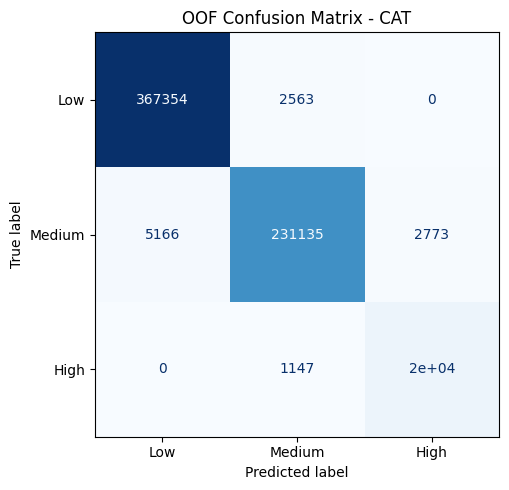

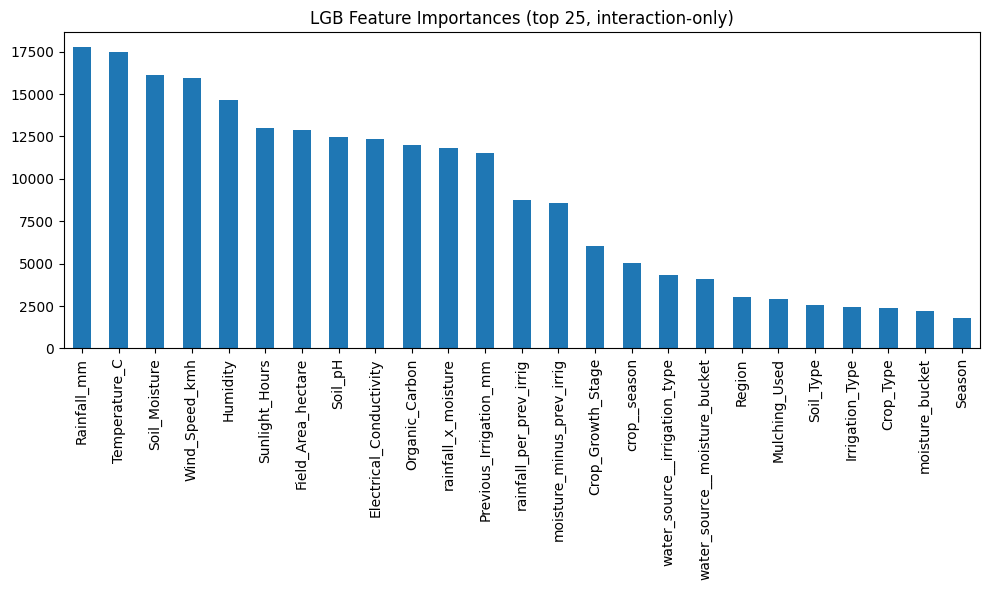

Top 20 importance features:
Rainfall_mm                      17756
Temperature_C                    17511
Soil_Moisture                    16152
Wind_Speed_kmh                   15929
Humidity                         14625
Sunlight_Hours                   12997
Field_Area_hectare               12910
Soil_pH                          12461
Electrical_Conductivity          12368
Organic_Carbon                   12022
rainfall_x_moisture              11799
Previous_Irrigation_mm           11507
rainfall_per_prev_irrig           8745
moisture_minus_prev_irrig         8553
Crop_Growth_Stage                 6013
crop__season                      5023
water_source__irrigation_type     4303
water_source__moisture_bucket     4067
Region                            3048
Mulching_Used                     2902


In [14]:
# Confusion matrix for best single model
best_oof = lgb_oof if lgb_score >= max(xgb_score, cat_score) else (xgb_oof if xgb_score >= cat_score else cat_oof)
best_name = model_names[model_scores.index(max(model_scores))]

cm = confusion_matrix(y.values, np.argmax(best_oof, axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"OOF Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

# Feature importance (LGB) on interaction-only features
lgb_model_final = build_lgb(n_classes)
lgb_model_final.fit(X_train, y)
importances = pd.Series(lgb_model_final.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(25).plot(kind="bar")
plt.title("LGB Feature Importances (top 25, interaction-only)")
plt.tight_layout()
plt.show()

print("Top 20 importance features:")
print(importances.head(20).to_string())

## OOF-Safe Ensemble + High-Class Thresholding + Calibration
Compare argmax, threshold-only, and threshold+calibration strategies using OOF probabilities, then choose the best strategy by balanced accuracy.

In [15]:
def apply_high_threshold(proba, high_idx, threshold):
    preds = np.argmax(proba, axis=1)
    preds[proba[:, high_idx] >= threshold] = high_idx
    return preds

def find_best_high_threshold(y_true, oof_proba, high_idx, grid=None):
    if grid is None:
        grid = np.linspace(0.15, 0.85, 71)

    base_preds = np.argmax(oof_proba, axis=1)
    base_score = balanced_accuracy_score(y_true, base_preds)

    best_t = 0.5
    best_score = base_score
    for t in grid:
        tuned_preds = apply_high_threshold(oof_proba, high_idx, float(t))
        score = balanced_accuracy_score(y_true, tuned_preds)
        if score > best_score:
            best_score = score
            best_t = float(t)
    return best_t, best_score, base_score

def fit_ovr_isotonic_calibrators(proba, y_true, n_classes):
    calibrators = []
    for cls in range(n_classes):
        iso = IsotonicRegression(out_of_bounds="clip")
        iso.fit(proba[:, cls], (y_true == cls).astype(int))
        calibrators.append(iso)
    return calibrators

def apply_ovr_isotonic_calibrators(proba, calibrators, eps=1e-12):
    calibrated = np.column_stack([
        calibrators[cls].transform(proba[:, cls]) for cls in range(len(calibrators))
    ])
    calibrated = np.clip(calibrated, eps, 1.0)
    row_sum = calibrated.sum(axis=1, keepdims=True)
    return calibrated / np.clip(row_sum, eps, None)

def crossfit_multiclass_calibration(oof_proba, y_true, n_classes, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    calibrated_oof = np.zeros_like(oof_proba)

    for tr_idx, val_idx in skf.split(oof_proba, y_true):
        fold_calibrators = fit_ovr_isotonic_calibrators(
            oof_proba[tr_idx], y_true[tr_idx], n_classes
        )
        calibrated_oof[val_idx] = apply_ovr_isotonic_calibrators(
            oof_proba[val_idx], fold_calibrators
        )

    full_calibrators = fit_ovr_isotonic_calibrators(oof_proba, y_true, n_classes)
    return calibrated_oof, full_calibrators

# Weighted average by OOF score (all 3 models)
total_score = lgb_score + xgb_score + cat_score
w_lgb = lgb_score / total_score
w_xgb = xgb_score / total_score
w_cat = cat_score / total_score

blend_oof = w_lgb * lgb_oof + w_xgb * xgb_oof + w_cat * cat_oof
blend_test = w_lgb * lgb_test + w_xgb * xgb_test + w_cat * cat_test
blend_score = balanced_accuracy_score(y.values, np.argmax(blend_oof, axis=1))
print(f"Weights(all3) → LGB: {w_lgb:.3f}, XGB: {w_xgb:.3f}, CAT: {w_cat:.3f}")
print(f"Blend(all3) OOF Balanced Accuracy: {blend_score:.5f}")

# Fallback weighted average (LGB + CAT only)
total_lc = lgb_score + cat_score
w_lgb_lc = lgb_score / total_lc
w_cat_lc = cat_score / total_lc
blend_lc_oof = w_lgb_lc * lgb_oof + w_cat_lc * cat_oof
blend_lc_test = w_lgb_lc * lgb_test + w_cat_lc * cat_test
blend_lc_score = balanced_accuracy_score(y.values, np.argmax(blend_lc_oof, axis=1))
print(f"Weights(LGB+CAT) → LGB: {w_lgb_lc:.3f}, CAT: {w_cat_lc:.3f}")
print(f"Blend(LGB+CAT) OOF Balanced Accuracy: {blend_lc_score:.5f}")

# Meta LogisticRegression stack
meta_train = np.hstack([lgb_oof, xgb_oof, cat_oof])
meta_test = np.hstack([lgb_test, xgb_test, cat_test])

from sklearn.linear_model import LogisticRegression as LR
meta_model = LR(C=1.0, max_iter=1000, random_state=42, class_weight="balanced", multi_class="auto")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_proba = np.zeros((len(y), n_classes), dtype=float)

for tr_idx, val_idx in skf.split(meta_train, y):
    meta_model.fit(meta_train[tr_idx], y.values[tr_idx])
    meta_oof_proba[val_idx] = meta_model.predict_proba(meta_train[val_idx])

meta_oof_pred = np.argmax(meta_oof_proba, axis=1)
meta_score = balanced_accuracy_score(y.values, meta_oof_pred)
print(f"Meta-LR OOF Balanced Accuracy: {meta_score:.5f}")

meta_model.fit(meta_train, y)
meta_test_proba = meta_model.predict_proba(meta_test)

# High-class threshold tuning on OOF predictions
HIGH_CLASS_IDX = label_map["High"]
blend_t, blend_t_score, blend_base = find_best_high_threshold(y.values, blend_oof, HIGH_CLASS_IDX)
blend_lc_t, blend_lc_t_score, blend_lc_base = find_best_high_threshold(y.values, blend_lc_oof, HIGH_CLASS_IDX)
meta_t, meta_t_score, meta_base = find_best_high_threshold(y.values, meta_oof_proba, HIGH_CLASS_IDX)

print("\nHigh threshold search (class=High):")
print(f"  blend(all3): base={blend_base:.5f}, tuned={blend_t_score:.5f}, t={blend_t:.3f}")
print(f"  blend(LGB+CAT): base={blend_lc_base:.5f}, tuned={blend_lc_t_score:.5f}, t={blend_lc_t:.3f}")
print(f"  meta-LR: base={meta_base:.5f}, tuned={meta_t_score:.5f}, t={meta_t:.3f}")

# OOF-safe calibration + threshold tuning
blend_cal_oof, blend_calibrators = crossfit_multiclass_calibration(blend_oof, y.values, n_classes)
blend_cal_test = apply_ovr_isotonic_calibrators(blend_test, blend_calibrators)

blend_lc_cal_oof, blend_lc_calibrators = crossfit_multiclass_calibration(blend_lc_oof, y.values, n_classes)
blend_lc_cal_test = apply_ovr_isotonic_calibrators(blend_lc_test, blend_lc_calibrators)

meta_cal_oof, meta_calibrators = crossfit_multiclass_calibration(meta_oof_proba, y.values, n_classes)
meta_cal_test = apply_ovr_isotonic_calibrators(meta_test_proba, meta_calibrators)

blend_cal_score = balanced_accuracy_score(y.values, np.argmax(blend_cal_oof, axis=1))
blend_lc_cal_score = balanced_accuracy_score(y.values, np.argmax(blend_lc_cal_oof, axis=1))
meta_cal_score = balanced_accuracy_score(y.values, np.argmax(meta_cal_oof, axis=1))

blend_cal_t, blend_cal_t_score, _ = find_best_high_threshold(y.values, blend_cal_oof, HIGH_CLASS_IDX)
blend_lc_cal_t, blend_lc_cal_t_score, _ = find_best_high_threshold(y.values, blend_lc_cal_oof, HIGH_CLASS_IDX)
meta_cal_t, meta_cal_t_score, _ = find_best_high_threshold(y.values, meta_cal_oof, HIGH_CLASS_IDX)

print("\nCalibration + high threshold search (class=High):")
print(f"  blend(all3): cal_argmax={blend_cal_score:.5f}, cal_tuned={blend_cal_t_score:.5f}, t={blend_cal_t:.3f}")
print(f"  blend(LGB+CAT): cal_argmax={blend_lc_cal_score:.5f}, cal_tuned={blend_lc_cal_t_score:.5f}, t={blend_lc_cal_t:.3f}")
print(f"  meta-LR: cal_argmax={meta_cal_score:.5f}, cal_tuned={meta_cal_t_score:.5f}, t={meta_cal_t:.3f}")

candidate_scores = {
    "lgb_argmax": lgb_score,
    "xgb_argmax": xgb_score,
    "cat_argmax": cat_score,
    "blend_all_argmax": blend_score,
    "blend_lgb_cat_argmax": blend_lc_score,
    "blend_all_high_threshold": blend_t_score,
    "blend_lgb_cat_high_threshold": blend_lc_t_score,
    "meta_argmax": meta_score,
    "meta_high_threshold": meta_t_score,
    "blend_all_calibrated_argmax": blend_cal_score,
    "blend_lgb_cat_calibrated_argmax": blend_lc_cal_score,
    "meta_calibrated_argmax": meta_cal_score,
    "blend_all_calibrated_high_threshold": blend_cal_t_score,
    "blend_lgb_cat_calibrated_high_threshold": blend_lc_cal_t_score,
    "meta_calibrated_high_threshold": meta_cal_t_score,
}

best_strategy = max(candidate_scores, key=candidate_scores.get)
best_oof_score = candidate_scores[best_strategy]

print("\nCandidate OOF summary:")
for k, v in sorted(candidate_scores.items(), key=lambda kv: kv[1], reverse=True):
    print(f"  {k:<40} {v:.5f}")

print(f"\nBest strategy: {best_strategy} (OOF={best_oof_score:.5f})")

Weights(all3) → LGB: 0.334, XGB: 0.332, CAT: 0.334
Blend(all3) OOF Balanced Accuracy: 0.96625
Weights(LGB+CAT) → LGB: 0.499, CAT: 0.501
Blend(LGB+CAT) OOF Balanced Accuracy: 0.96785
Meta-LR OOF Balanced Accuracy: 0.97033

High threshold search (class=High):
  blend(all3): base=0.96625, tuned=0.97105, t=0.200
  blend(LGB+CAT): base=0.96785, tuned=0.97100, t=0.290
  meta-LR: base=0.97033, tuned=0.97045, t=0.460

Calibration + high threshold search (class=High):
  blend(all3): cal_argmax=0.96454, cal_tuned=0.97031, t=0.150
  blend(LGB+CAT): cal_argmax=0.96641, cal_tuned=0.96971, t=0.150
  meta-LR: cal_argmax=0.96699, cal_tuned=0.96974, t=0.150

Candidate OOF summary:
  blend_all_high_threshold                 0.97105
  blend_lgb_cat_high_threshold             0.97100
  meta_high_threshold                      0.97045
  meta_argmax                              0.97033
  blend_all_calibrated_high_threshold      0.97031
  meta_calibrated_high_threshold           0.96974
  blend_lgb_cat_calib

## Generate Submission

In [16]:
os.makedirs(output_dir, exist_ok=True)

if best_strategy == "lgb_argmax":
    final_test_pred = np.argmax(lgb_test, axis=1)
elif best_strategy == "xgb_argmax":
    final_test_pred = np.argmax(xgb_test, axis=1)
elif best_strategy == "cat_argmax":
    final_test_pred = np.argmax(cat_test, axis=1)
elif best_strategy == "blend_all_argmax":
    final_test_pred = np.argmax(blend_test, axis=1)
elif best_strategy == "blend_lgb_cat_argmax":
    final_test_pred = np.argmax(blend_lc_test, axis=1)
elif best_strategy == "blend_all_high_threshold":
    final_test_pred = apply_high_threshold(blend_test, HIGH_CLASS_IDX, blend_t)
elif best_strategy == "blend_lgb_cat_high_threshold":
    final_test_pred = apply_high_threshold(blend_lc_test, HIGH_CLASS_IDX, blend_lc_t)
elif best_strategy == "meta_high_threshold":
    final_test_pred = apply_high_threshold(meta_test_proba, HIGH_CLASS_IDX, meta_t)
elif best_strategy == "blend_all_calibrated_argmax":
    final_test_pred = np.argmax(blend_cal_test, axis=1)
elif best_strategy == "blend_lgb_cat_calibrated_argmax":
    final_test_pred = np.argmax(blend_lc_cal_test, axis=1)
elif best_strategy == "meta_calibrated_argmax":
    final_test_pred = np.argmax(meta_cal_test, axis=1)
elif best_strategy == "blend_all_calibrated_high_threshold":
    final_test_pred = apply_high_threshold(blend_cal_test, HIGH_CLASS_IDX, blend_cal_t)
elif best_strategy == "blend_lgb_cat_calibrated_high_threshold":
    final_test_pred = apply_high_threshold(blend_lc_cal_test, HIGH_CLASS_IDX, blend_lc_cal_t)
elif best_strategy == "meta_calibrated_high_threshold":
    final_test_pred = apply_high_threshold(meta_cal_test, HIGH_CLASS_IDX, meta_cal_t)
else:
    final_test_pred = np.argmax(meta_test_proba, axis=1)

final_test_labels = [inv_label_map[p] for p in final_test_pred]
print(f"Using: {best_strategy} (OOF={best_oof_score:.5f})")

sub = pd.DataFrame({
    "id": test_df["id"],
    "Irrigation_Need": final_test_labels
})

out_path = f"{output_dir}/submission.csv"
sub.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(sub["Irrigation_Need"].value_counts())
sub.head()

Using: blend_all_high_threshold (OOF=0.97105)
Saved: /kaggle/working/submission.csv
Irrigation_Need
Low       159809
Medium     99740
High       10451
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## Optuna CatBoost Tuning Progress (2026-04-29)

Local run was intentionally stopped for the night.

Progress snapshot before stop:
- Completed: 16 / 60 trials (27%)
- Best trial id: 15
- Best 3-fold balanced accuracy: **0.970763**

Current CAT baseline in this notebook/pipeline is **0.96842** OOF.

Next step on Kaggle:
1. Run the Optuna cell below.
2. Copy `study.best_params` into `build_cat()`.
3. Re-run CAT 5-fold and compare OOF.

In [ ]:
# # Optuna tuning cell for CatBoost (run this on Kaggle)
# import optuna
# from catboost import CatBoostClassifier
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import balanced_accuracy_score

# optuna.logging.set_verbosity(optuna.logging.WARNING)

# SEED = 42
# N_TRIALS = 60
# TIMEOUT = 60 * 60  # 1 hour


# def make_cat_objective(X, y, n_folds=3, seed=42):
#     skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
#     folds = list(skf.split(X, y))

#     def objective(trial):
#         params = {
#             "iterations": trial.suggest_int("iterations", 500, 1500),
#             "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
#             "depth": trial.suggest_int("depth", 4, 10),
#             "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
#             "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
#             "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
#             "border_count": trial.suggest_int("border_count", 32, 255),
#             "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Lossguide"]),
#             "auto_class_weights": trial.suggest_categorical("auto_class_weights", ["Balanced", "None"]),
#             "loss_function": "MultiClass",
#             "eval_metric": "Accuracy",
#             "random_seed": seed,
#             "verbose": 0,
#             "use_best_model": True,
#         }
#         if params["auto_class_weights"] == "None":
#             params["auto_class_weights"] = None

#         scores = []
#         for tr_idx, val_idx in folds:
#             X_tr, X_val = X_train[tr_idx], X_train[val_idx]
#             y_tr, y_val = y.values[tr_idx], y.values[val_idx]

#             model = CatBoostClassifier(**params)
#             model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=80)

#             preds = model.predict(X_val).reshape(-1)
#             scores.append(balanced_accuracy_score(y_val, preds))

#         return float(np.mean(scores))

#     return objective


# study = optuna.create_study(
#     direction="maximize",
#     study_name="catboost_s6e4",
#     sampler=optuna.samplers.TPESampler(seed=SEED),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=0),
# )

# objective = make_cat_objective(X_train, y, n_folds=3, seed=SEED)

# study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT, show_progress_bar=True)

# print("Best 3-fold score:", round(study.best_value, 6))
# print("Best params:")
# for k, v in study.best_params.items():
#     print(f"  {k}: {v}")

# best_params = study.best_params.copy()
# if best_params.get("auto_class_weights") == "None":
#     best_params["auto_class_weights"] = None

# best_params

  0%|          | 0/60 [00:00<?, ?it/s]

Best 3-fold score: 0.969922
Best params:
  iterations: 1388
  learning_rate: 0.035922606902684895
  depth: 4
  l2_leaf_reg: 11.312251057160324
  bagging_temperature: 0.7607850486168974
  random_strength: 5.612771975694963
  border_count: 204
  grow_policy: Lossguide
  auto_class_weights: Balanced


{'iterations': 1388,
 'learning_rate': 0.035922606902684895,
 'depth': 4,
 'l2_leaf_reg': 11.312251057160324,
 'bagging_temperature': 0.7607850486168974,
 'random_strength': 5.612771975694963,
 'border_count': 204,
 'grow_policy': 'Lossguide',
 'auto_class_weights': 'Balanced'}